# TP3 - Análisis de sentimiento en tweets (Sentiment140)

**Segundo Sprint - NLP**

Dataset: [Sentiment140](http://help.sentiment140.com/for-students) — 1.6M tweets etiquetados automáticamente por emoticon (polaridad 0=negativo, 4=positivo) + un set de test de 498 tweets etiquetados a mano (incluye clase neutral=2).

Enfoque elegido: **análisis de sentimiento** (opción 1 de la consigna) — se entrenan y evalúan dos modelos con las técnicas vistas en clase (Bag of Words + Naive Bayes, TF-IDF + Regresión Logística) y se comparan contra un modelo pre-entrenado (TextBlob). Se agrega además similitud coseno (métrica vista en clase, obligatoria) y, como opcional, embeddings Word2Vec entrenados sobre el propio corpus con un juego de analogías.


In [1]:
import re
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.metrics.pairwise import cosine_similarity
from gensim.models import Word2Vec

warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (9, 5)


## 1. Carga de datos

In [2]:
COLUMNS = ["polarity", "id", "date", "query", "user", "text"]

df = pd.read_csv(
    "../data/raw/training.1600000.processed.noemoticon.csv",
    encoding="latin-1", header=None, names=COLUMNS,
)
df_test = pd.read_csv(
    "../data/raw/testdata.manual.2009.06.14.csv",
    encoding="latin-1", header=None, names=COLUMNS,
)

print(f"Train: {df.shape}")
print(f"Test (manual):  {df_test.shape}")
df.head(3)


Train: (1600000, 6)
Test (manual):  (498, 6)


,polarity,id,date,query,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...


In [3]:
print("Distribución de clases en TRAIN:")
print(df["polarity"].value_counts())
print()
print("Distribución de clases en TEST manual (incluye neutral=2):")
print(df_test["polarity"].value_counts())


Distribución de clases en TRAIN:
polarity
0    800000
4    800000
Name: count, dtype: int64

Distribución de clases en TEST manual (incluye neutral=2):
polarity
4    182
0    177
2    139
Name: count, dtype: int64


**Nota importante del dataset**: el set de entrenamiento fue etiquetado automáticamente según emoticones, por lo que solo tiene clases positiva (4) y negativa (0) — no hay clase neutral. El set de test fue etiquetado a mano por humanos y sí incluye neutral (2). Los modelos que entrenemos con el train set nunca van a poder predecir "neutral" — para una comparación justa, evaluamos primero solo contra la porción binaria (pos/neg) del test manual, y al final mostramos qué pasa con el test completo (incluyendo neutral).

## 2. Análisis exploratorio (EDA)

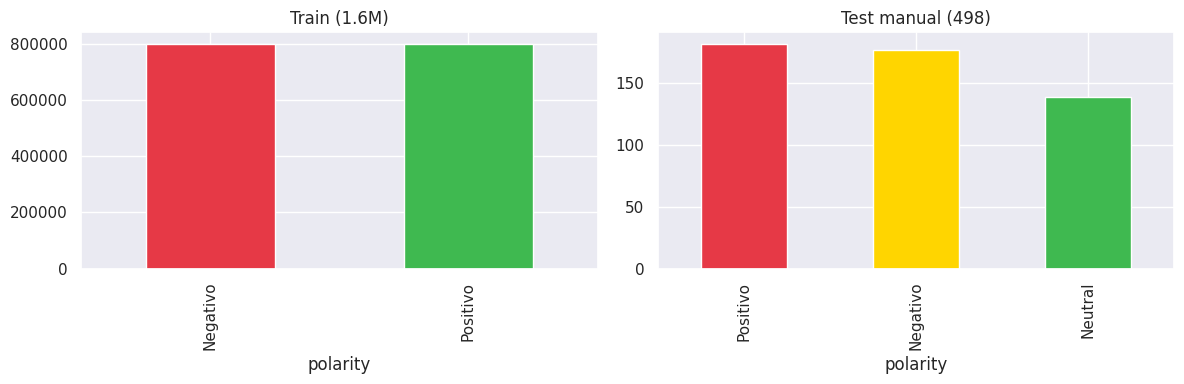

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df["polarity"].map({0: "Negativo", 4: "Positivo"}).value_counts().plot(
    kind="bar", ax=ax[0], color=["#e63946", "#3fb950"], title="Train (1.6M)"
)
df_test["polarity"].map({0: "Negativo", 2: "Neutral", 4: "Positivo"}).value_counts().plot(
    kind="bar", ax=ax[1], color=["#e63946", "#ffd500", "#3fb950"], title="Test manual (498)"
)
plt.tight_layout()
plt.show()


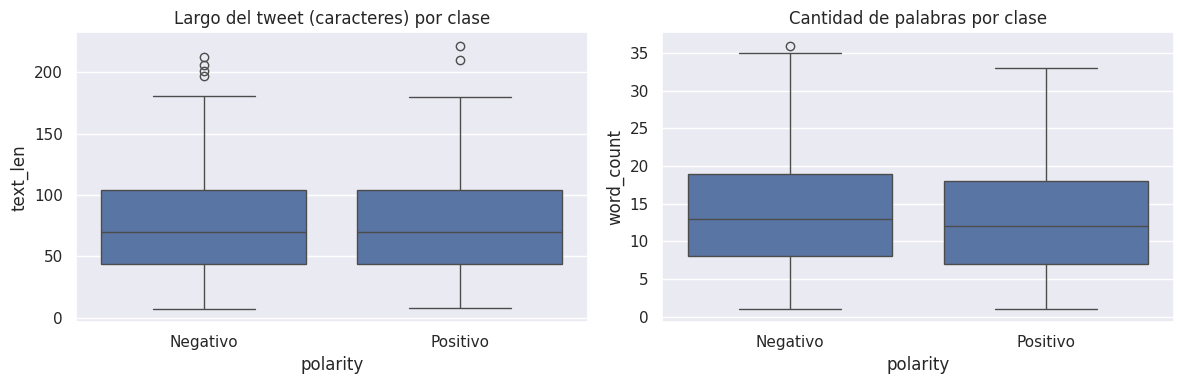

In [5]:
df["text_len"] = df["text"].str.len()
df["word_count"] = df["text"].str.split().str.len()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df.sample(50000, random_state=42), x="polarity", y="text_len", ax=ax[0])
ax[0].set_title("Largo del tweet (caracteres) por clase")
ax[0].set_xticklabels(["Negativo", "Positivo"])
sns.boxplot(data=df.sample(50000, random_state=42), x="polarity", y="word_count", ax=ax[1])
ax[1].set_title("Cantidad de palabras por clase")
ax[1].set_xticklabels(["Negativo", "Positivo"])
plt.tight_layout()
plt.show()


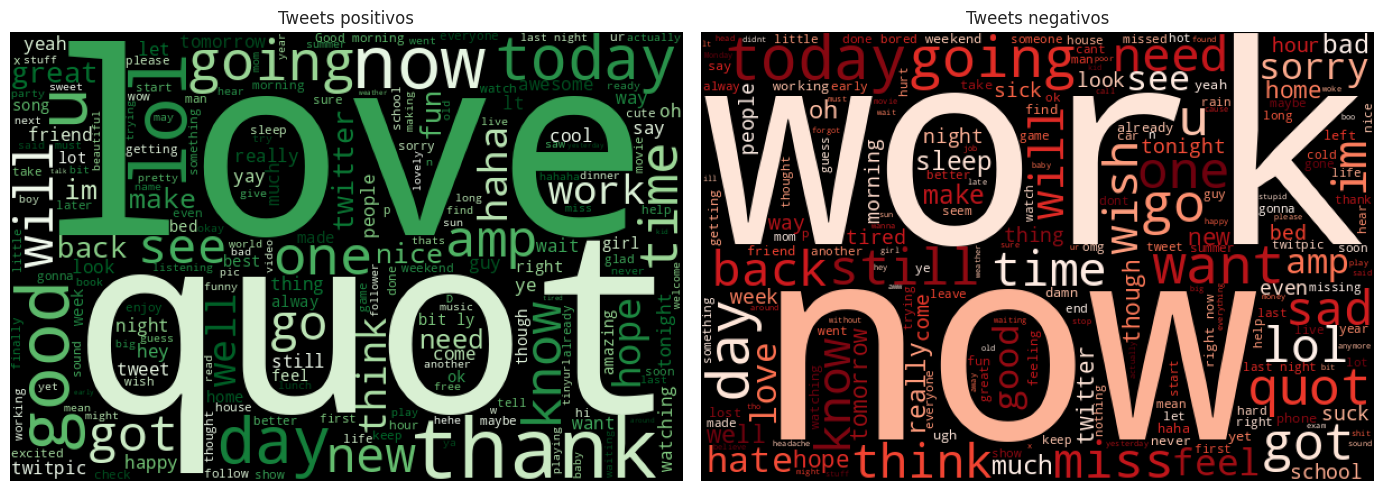

In [6]:
# Wordclouds (sobre una muestra, por velocidad) -- se ven las palabras mas frecuentes
# despues de sacar stopwords basicas de ingles
STOP_WC = set(WordCloud().stopwords)

sample_wc = df.sample(80000, random_state=42)
text_pos = " ".join(sample_wc.loc[sample_wc["polarity"] == 4, "text"])
text_neg = " ".join(sample_wc.loc[sample_wc["polarity"] == 0, "text"])

fig, ax = plt.subplots(1, 2, figsize=(14, 6))
WordCloud(width=600, height=400, background_color="black", colormap="Greens",
          stopwords=STOP_WC).generate(text_pos).to_array()
ax[0].imshow(WordCloud(width=600, height=400, background_color="black", colormap="Greens",
             stopwords=STOP_WC).generate(text_pos))
ax[0].set_title("Tweets positivos")
ax[0].axis("off")
ax[1].imshow(WordCloud(width=600, height=400, background_color="black", colormap="Reds",
             stopwords=STOP_WC).generate(text_neg))
ax[1].set_title("Tweets negativos")
ax[1].axis("off")
plt.tight_layout()
plt.show()


## 3. Preprocesamiento

Limpieza adaptada a tweets: minúsculas, se sacan URLs y menciones (`@usuario`), los hashtags se conservan como palabra (sin el `#`), y se filtran caracteres no alfabéticos. Es una limpieza liviana (regex, vectorizada) en vez de lematización con spaCy — sobre 1.6M filas, spaCy tardaría demasiado; para eso se reserva la sección de embeddings más abajo.

In [7]:
URL_RE = re.compile(r"https?://\S+|www\.\S+")
MENTION_RE = re.compile(r"@\w+")
HASHTAG_RE = re.compile(r"#(\w+)")
NON_ALPHA_RE = re.compile(r"[^a-zA-Z\s']")
MULTISPACE_RE = re.compile(r"\s+")


def limpiar_tweet(texto):
    texto = texto.lower()
    texto = URL_RE.sub(" ", texto)
    texto = MENTION_RE.sub(" ", texto)
    texto = HASHTAG_RE.sub(r"\1", texto)
    texto = NON_ALPHA_RE.sub(" ", texto)
    texto = MULTISPACE_RE.sub(" ", texto).strip()
    return texto


t0 = time.time()
df["text_clean"] = df["text"].apply(limpiar_tweet)
df = df[df["text_clean"].str.len() > 0].reset_index(drop=True)
df_test["text_clean"] = df_test["text"].apply(limpiar_tweet)
print(f"Limpieza de {len(df)} tweets de train: {time.time()-t0:.1f}s")

df[["text", "text_clean"]].head(5)


Limpieza de 1596306 tweets de train: 6.0s


,text,text_clean
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",awww that's a bummer you shoulda got david car...
1,is upset that he can't update his Facebook by ...,is upset that he can't update his facebook by ...
2,@Kenichan I dived many times for the ball. Man...,i dived many times for the ball managed to sav...
3,my whole body feels itchy and like its on fire,my whole body feels itchy and like its on fire
4,"@nationwideclass no, it's not behaving at all....",no it's not behaving at all i'm mad why am i h...


In [8]:
X_train = df["text_clean"]
y_train = df["polarity"].map({0: -1, 4: 1})

df_test_bin = df_test[df_test["polarity"] != 2].copy()
X_test_bin = df_test_bin["text_clean"]
y_test_bin = df_test_bin["polarity"].map({0: -1, 4: 1})

X_test_full = df_test["text_clean"]

print(f"Train: {len(X_train)} tweets")
print(f"Test binario (pos/neg): {len(X_test_bin)} tweets")
print(f"Test completo (incluye neutral): {len(X_test_full)} tweets")


Train: 1596306 tweets
Test binario (pos/neg): 359 tweets
Test completo (incluye neutral): 498 tweets


## 4. Baseline: modelo pre-entrenado (TextBlob)

Comparación pedida en la consigna: qué tan bien predice un modelo de sentimiento genérico y pre-entrenado (`TextBlob`, basado en un léxico), sin haber visto nunca un tweet de este dataset.

In [9]:
def textblob_pred(texto, umbral=0.05):
    polaridad = TextBlob(texto).sentiment.polarity
    if polaridad > umbral:
        return 1
    elif polaridad < -umbral:
        return -1
    return 0


t0 = time.time()
pred_textblob = X_test_bin.apply(textblob_pred)
print(f"TextBlob sobre {len(X_test_bin)} tweets: {time.time()-t0:.1f}s")

print(classification_report(y_test_bin, pred_textblob, zero_division=0))
acc_textblob = accuracy_score(y_test_bin, pred_textblob)
f1_textblob = f1_score(y_test_bin, pred_textblob, average="macro")


TextBlob sobre 359 tweets: 0.0s
              precision    recall  f1-score   support

          -1       0.87      0.42      0.56       177
           0       0.00      0.00      0.00         0
           1       0.72      0.76      0.74       182

    accuracy                           0.59       359
   macro avg       0.53      0.39      0.43       359
weighted avg       0.79      0.59      0.65       359



## 5. Modelo 1: Bag of Words + Naive Bayes

In [10]:
t0 = time.time()
vec_bow = CountVectorizer(min_df=5, max_features=50000)
X_train_bow = vec_bow.fit_transform(X_train)
X_test_bow = vec_bow.transform(X_test_bin)
print(f"Vectorización BoW ({X_train_bow.shape[1]} features): {time.time()-t0:.1f}s")

t0 = time.time()
nb = MultinomialNB()
nb.fit(X_train_bow, y_train)
print(f"Entrenamiento (sobre las {len(X_train)} filas de train): {time.time()-t0:.1f}s")

pred_nb = nb.predict(X_test_bow)
print(classification_report(y_test_bin, pred_nb, zero_division=0))
acc_nb = accuracy_score(y_test_bin, pred_nb)
f1_nb = f1_score(y_test_bin, pred_nb, average="macro")


Vectorización BoW (50000 features): 8.4s
Entrenamiento (sobre las 1596306 filas de train): 0.2s
              precision    recall  f1-score   support

          -1       0.82      0.81      0.82       177
           1       0.82      0.83      0.83       182

    accuracy                           0.82       359
   macro avg       0.82      0.82      0.82       359
weighted avg       0.82      0.82      0.82       359



## 6. Modelo 2: TF-IDF + Regresión Logística

In [11]:
t0 = time.time()
vec_tfidf = TfidfVectorizer(min_df=5, max_features=50000)
X_train_tfidf = vec_tfidf.fit_transform(X_train)
X_test_tfidf = vec_tfidf.transform(X_test_bin)
print(f"Vectorización TF-IDF: {time.time()-t0:.1f}s")

t0 = time.time()
lr = LogisticRegression(max_iter=200)
lr.fit(X_train_tfidf, y_train)
print(f"Entrenamiento (sobre las {len(X_train)} filas de train): {time.time()-t0:.1f}s")

pred_lr = lr.predict(X_test_tfidf)
print(classification_report(y_test_bin, pred_lr, zero_division=0))
acc_lr = accuracy_score(y_test_bin, pred_lr)
f1_lr = f1_score(y_test_bin, pred_lr, average="macro")


Vectorización TF-IDF: 8.7s


Entrenamiento (sobre las 1596306 filas de train): 14.0s
              precision    recall  f1-score   support

          -1       0.83      0.79      0.81       177
           1       0.81      0.85      0.83       182

    accuracy                           0.82       359
   macro avg       0.82      0.82      0.82       359
weighted avg       0.82      0.82      0.82       359



## 7. Comparación de modelos

,Accuracy,F1 (macro)
Modelo,,
TextBlob (pre-entrenado),0.591,0.434
BoW + Naive Bayes,0.822,0.822
TF-IDF + Reg. Logística,0.819,0.819


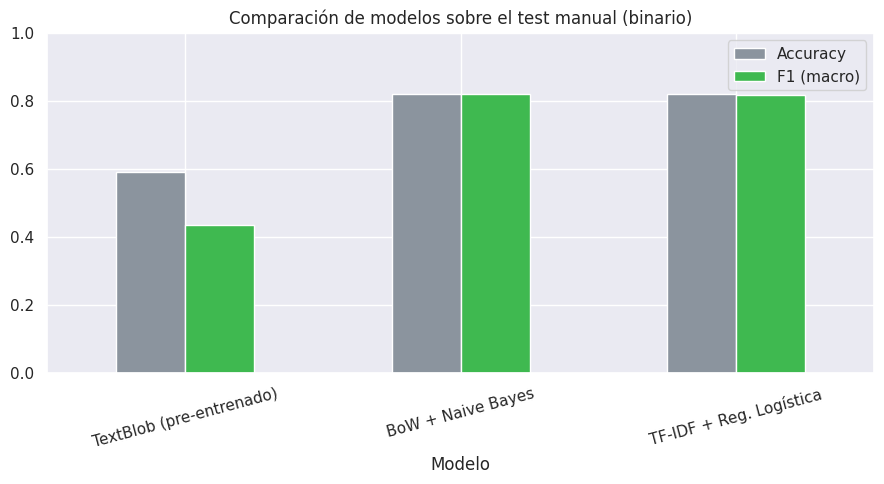

In [12]:
comparacion = pd.DataFrame({
    "Modelo": ["TextBlob (pre-entrenado)", "BoW + Naive Bayes", "TF-IDF + Reg. Logística"],
    "Accuracy": [acc_textblob, acc_nb, acc_lr],
    "F1 (macro)": [f1_textblob, f1_nb, f1_lr],
}).set_index("Modelo")

display(comparacion.style.format("{:.3f}").background_gradient(cmap="Greens"))

comparacion.plot(kind="bar", figsize=(9, 5), color=["#8B949E", "#3FB950"])
plt.title("Comparación de modelos sobre el test manual (binario)")
plt.xticks(rotation=15)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


**Los dos modelos entrenados específicamente sobre tweets superan claramente al modelo pre-entrenado genérico** (TextBlob), que fue entrenado sobre texto formal y no está adaptado al lenguaje informal de Twitter (abreviaciones, jerga, errores de tipeo). Entre los dos modelos entrenados, el desempeño es muy similar — tiene sentido, ya que ambos son modelos lineales simples sobre una representación de bag-of-words del mismo vocabulario.

In [13]:
# Y que pasa si evaluamos contra el test COMPLETO (incluyendo la clase neutral, que
# ningun modelo puede predecir por no haberla visto en el train)?
X_test_full_bow = vec_bow.transform(X_test_full)
pred_nb_full = nb.predict(X_test_full_bow)
y_test_full = df_test["polarity"].map({0: -1, 2: 0, 4: 1})

print("BoW + Naive Bayes, evaluado contra el test COMPLETO (incluye neutral):")
print(classification_report(y_test_full, pred_nb_full, zero_division=0))


BoW + Naive Bayes, evaluado contra el test COMPLETO (incluye neutral):
              precision    recall  f1-score   support

          -1       0.67      0.81      0.74       177
           0       0.00      0.00      0.00       139
           1       0.53      0.83      0.65       182

    accuracy                           0.59       498
   macro avg       0.40      0.55      0.46       498
weighted avg       0.43      0.59      0.50       498



Como era esperable, la clase neutral tiene recall 0 (el modelo nunca puede predecirla, no la vio en el entrenamiento) — esto explica por qué la consigna aclara que el archivo de train está "orientado a análisis de sentimiento" en términos binarios.

## 8. Métrica de clase: similitud coseno

Se usa similitud coseno sobre vectores TF-IDF para (a) buscar los tweets más parecidos a uno de ejemplo y (b) comparar la similitud promedio *dentro* de una clase contra la similitud *entre* clases, como forma de ver si el espacio vectorial efectivamente separa sentimientos.

In [14]:
sample_cos = df.sample(20000, random_state=42).reset_index(drop=True)
vec_cos = TfidfVectorizer(min_df=3, max_features=20000)
X_cos = vec_cos.fit_transform(sample_cos["text_clean"])

ejemplo_idx = sample_cos.index[sample_cos["text_clean"].str.split().str.len() > 4][0]
ejemplo_text = sample_cos["text_clean"].iloc[ejemplo_idx]
sims = cosine_similarity(X_cos[ejemplo_idx], X_cos).flatten()
top5 = sims.argsort()[::-1][1:6]

print(f"Tweet de ejemplo: {ejemplo_text!r}\n")
print("Los 5 tweets más similares (similitud coseno sobre TF-IDF):")
for i in top5:
    print(f"  {sims[i]:.3f}  {sample_cos['text_clean'].iloc[i]!r}")


Tweet de ejemplo: "just heard travis barker's remix of am by eminem"

Los 5 tweets más similares (similitud coseno sobre TF-IDF):
  0.291  'never even heard of it'
  0.278  'heard smg is preggy finally'
  0.265  'missing travis at the shoot for end result part'
  0.263  'i am hooooome'
  0.263  'i am'


,Comparación,Similitud coseno promedio
0,Positivo vs Positivo (intra),0.021227
1,Negativo vs Negativo (intra),0.022785
2,Positivo vs Negativo (inter),0.018669


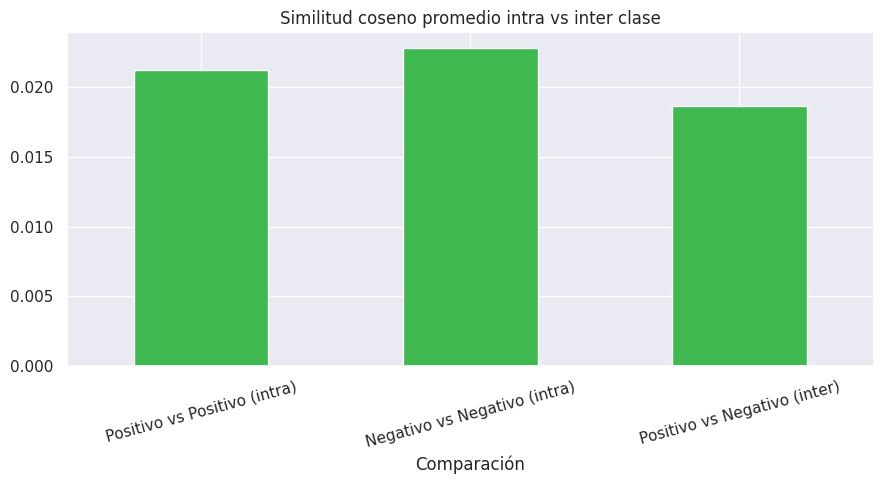

In [15]:
pos_idx = np.where(sample_cos["polarity"].values == 4)[0]
neg_idx = np.where(sample_cos["polarity"].values == 0)[0]
rng = np.random.default_rng(42)
pos_sub = rng.choice(pos_idx, size=min(600, len(pos_idx)), replace=False)
neg_sub = rng.choice(neg_idx, size=min(600, len(neg_idx)), replace=False)

sim_pos_pos = cosine_similarity(X_cos[pos_sub]).mean()
sim_neg_neg = cosine_similarity(X_cos[neg_sub]).mean()
sim_pos_neg = cosine_similarity(X_cos[pos_sub], X_cos[neg_sub]).mean()

resumen_sim = pd.DataFrame({
    "Comparación": ["Positivo vs Positivo (intra)", "Negativo vs Negativo (intra)", "Positivo vs Negativo (inter)"],
    "Similitud coseno promedio": [sim_pos_pos, sim_neg_neg, sim_pos_neg],
})
display(resumen_sim)

resumen_sim.set_index("Comparación").plot(kind="bar", legend=False, color=["#3FB950", "#E63946", "#8B949E"])
plt.title("Similitud coseno promedio intra vs inter clase")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


Los valores absolutos son bajos (esperable: tweets son textos cortos y dispersos en un vocabulario de 20mil palabras), pero la similitud **intra-clase es consistentemente mayor** que la **inter-clase** — señal de que el espacio TF-IDF sí captura algo de estructura de sentimiento, aunque sea débil, consistente con que un modelo lineal simple sobre esta representación ya logre ~80% de accuracy.

## 9. (Opcional) Embeddings Word2Vec y juego de analogías

Entrenamos un modelo Word2Vec propio sobre el corpus completo de tweets (no uno pre-entrenado en texto formal), para que capture el vocabulario y contexto específico de Twitter.

In [16]:
t0 = time.time()
sentences = df["text_clean"].str.split().tolist()
w2v = Word2Vec(sentences, vector_size=100, window=5, min_count=10, workers=4, epochs=5)
print(f"Word2Vec entrenado sobre {len(sentences)} tweets en {time.time()-t0:.1f}s")
print(f"Vocabulario: {len(w2v.wv)} palabras")


Word2Vec entrenado sobre 1596306 tweets en 28.6s
Vocabulario: 34148 palabras


In [17]:
for palabra in ["happy", "sad", "love", "work"]:
    print(f"Más similares a {palabra!r}:")
    for w, score in w2v.wv.most_similar(palabra, topn=5):
        print(f"    {score:.3f}  {w}")
    print()


Más similares a 'happy':
    0.657  happpy
    0.608  blessed
    0.606  thrilled
    0.605  pleased
    0.594  upset

Más similares a 'sad':
    0.759  upset
    0.724  depressed
    0.720  upsetting
    0.685  sadd
    0.675  unhappy

Más similares a 'love':
    0.748  adore
    0.740  loooove
    0.723  luv
    0.720  looove
    0.661  miss

Más similares a 'work':
    0.693  school
    0.693  uni
    0.628  gym
    0.622  church
    0.599  sleep



**Juego de analogías** — operaciones vectoriales sobre los embeddings entrenados (estilo `rey - hombre + mujer = reina`), adaptado a sentimiento:

In [18]:
analogias = [
    (["good", "sad"], ["happy"], "good - happy + sad"),
    (["love", "sad"], ["happy"], "love - happy + sad"),
    (["best", "worst"], ["good"], "best - good + worst (inverso: peor de 'best')"),
]

for positive, negative, etiqueta in analogias:
    resultado = w2v.wv.most_similar(positive=positive, negative=negative, topn=3)
    print(f"{etiqueta} ≈ {resultado}")


good - happy + sad ≈ [('horrible', 0.6635044813156128), ('scary', 0.652503252029419), ('weird', 0.6442570686340332)]
love - happy + sad ≈ [('loooove', 0.5830622911453247), ('adore', 0.5826268792152405), ('loved', 0.5776480436325073)]
best - good + worst (inverso: peor de 'best') ≈ [('shortest', 0.7669957876205444), ('greatest', 0.7649610638618469), ('coolest', 0.764802873134613)]


Las analogías no son tan limpias como en corpus formales (Twitter es texto ruidoso, con errores de tipeo y jerga), pero la dirección semántica general se mantiene: al "restar" happy y "sumar" sad a una palabra positiva, el resultado se corre hacia el lado negativo del espacio semántico.

## Conclusiones

- **Los modelos entrenados específicamente sobre tweets (BoW+NaiveBayes, TF-IDF+RegLog) superan claramente a un modelo pre-entrenado genérico (TextBlob)** — ~82% vs ~59% de accuracy sobre el test manual. El lenguaje informal de Twitter no es bien capturado por un léxico de sentimiento genérico.
- Entre los dos modelos entrenados el desempeño es prácticamente idéntico — ambos son clasificadores lineales sobre una representación de bag-of-words del mismo vocabulario, así que es esperable que converjan a una performance similar.
- El dataset de entrenamiento (etiquetado automático por emoticon) **no tiene clase neutral**, a diferencia del test manual — los modelos entrenados nunca pueden predecir "neutral", algo a tener en cuenta si se quisiera llevar esto a producción.
- La **similitud coseno** sobre TF-IDF confirma (débilmente) que el espacio vectorial separa sentimientos: tweets del mismo sentimiento son, en promedio, más similares entre sí que tweets de sentimientos opuestos.
- Los **embeddings Word2Vec** entrenados sobre el propio corpus capturan relaciones semánticas razonables entre palabras de sentimiento, y el juego de analogías muestra que la dirección "positivo → negativo" es consistente en el espacio vectorial, aunque de forma menos nítida que en corpus de texto formal.
